In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plntxps import *

In [2]:
data = np.array([2, 2, 5, 1, 1]) - 1

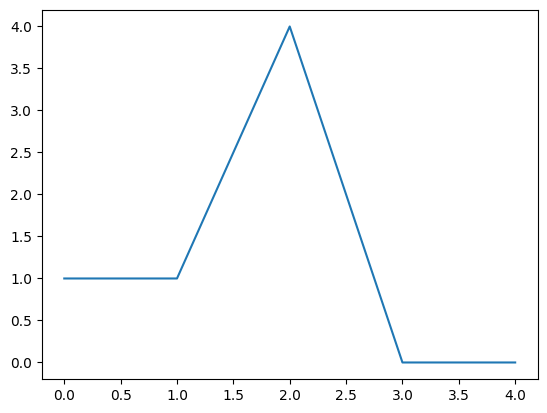

In [3]:
plt.plot(data)

In [4]:
RhAl2O3 = datafile("example data/2024-09-16 Rh on Al2O3 for Marlon 7-21-24 fit.xy")

(300.0, 1200.0)

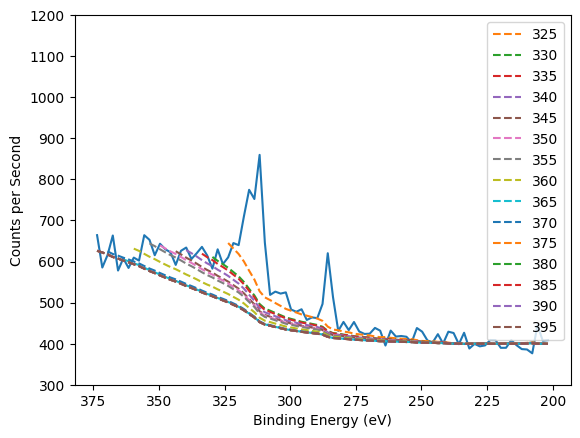

In [5]:
slice_upper_bounds = np.arange(325, 400, 5)
guinea_pig = RhAl2O3.spectra[0].slice(200, 375)
guinea_pig.plot()
for upper_bound in slice_upper_bounds:
    background_slice = guinea_pig.slice(200, upper_bound)
    background = shirley_background(background_slice.counts, 100)[-1]
    plt.plot(
        background_slice.eV, background,
        ls = 'dashed', label = upper_bound)

plt.legend()
boilerplate()
#plt.xlim(400, 200)
plt.ylim(3e2, 1.2e3)

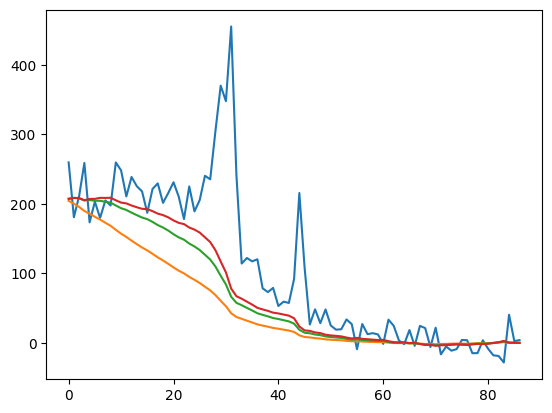

In [10]:
counts = (guinea_pig.counts - np.mean(guinea_pig.counts[-5:]))
plt.plot(counts)
step_height = 210
def background(counts, step_height):
    sum_counts = np.sum(counts)
    sum_past_point = []
    for n in range(0, len(counts)):
        sum_past_point.append(np.sum(counts[n+1:]))
    return sum_past_point/sum_counts * step_height
background_1 = background(counts, step_height)
background_2 = background(counts - background_1, step_height)
background_3 = background(counts - background_2, step_height)
plt.plot(background_1)
plt.plot(background_2)
plt.plot(background_3)